![Credit card being held in hand](credit_card.jpg)

Commercial banks receive _a lot_ of applications for credit cards. Many of them get rejected for many reasons, like high loan balances, low income levels, or too many inquiries on an individual's credit report, for example. Manually analyzing these applications is mundane, error-prone, and time-consuming (and time is money!). Luckily, this task can be automated with the power of machine learning and pretty much every commercial bank does so nowadays. In this workbook, we will build an automatic credit card approval predictor using machine learning techniques, just like real banks do.

### The Data

The data is a small subset of the Credit Card Approval dataset from the UCI Machine Learning Repository showing the credit card applications a bank receives. This dataset has been loaded as a `pandas` DataFrame called `cc_apps`. The last column in the dataset is the target value.

In [69]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV

# Load the dataset
cc_apps = pd.read_csv("cc_approvals.data", header=None) 
cc_apps.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,g,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,g,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,g,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,g,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,s,0,+


In [70]:
# Transform column 1 into a numerical column
cc_apps[1] = pd.to_numeric(cc_apps[1],errors='coerce')
cc_apps.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,g,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,g,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,g,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,g,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,s,0,+


In [71]:
# Check for missing values
print(cc_apps.isna().sum().sort_values())
cc_apps[cc_apps[1].isnull()]

0      0
2      0
3      0
4      0
5      0
6      0
7      0
8      0
9      0
10     0
11     0
12     0
13     0
1     12
dtype: int64


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
83,a,NaN,3.500,u,g,d,v,3.000,t,f,0,g,0,-
86,b,NaN,0.375,u,g,d,v,0.875,t,f,0,s,0,-
92,b,NaN,5.000,y,p,aa,v,8.500,t,f,0,g,0,-
97,b,NaN,0.500,u,g,c,bb,0.835,t,f,0,s,0,-
254,b,NaN,0.625,u,g,k,v,0.250,f,f,0,g,2010,-
286,a,NaN,1.500,u,g,ff,ff,0.000,f,t,2,g,105,-
329,b,NaN,4.000,y,p,i,v,0.085,f,f,0,g,0,-
445,a,NaN,11.250,u,g,ff,ff,0.000,f,f,0,g,5200,-
450,b,NaN,3.000,y,p,i,bb,7.000,f,f,0,g,1,-
500,b,NaN,4.000,u,g,x,v,5.000,t,t,3,g,2279,+


In [72]:
# Drop the missing rows
cc_apps_new = cc_apps.copy()
cc_apps_new[1] = cc_apps_new[1].replace(" ",np.nan)
cc_apps_new[cc_apps_new[1].isna()]
# Imputation process
cc_apps_new[1] = cc_apps_new[1].fillna(cc_apps_new[1].mean())

print(cc_apps_new.isna().sum().sort_values())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64


In [73]:
# Write variables as binary ones
# Print the columns to check their names
print(cc_apps_new.columns)

# If the columns are integers, use integers instead of strings
cc_dummies = pd.get_dummies(cc_apps_new[[0, 3, 4, 5, 6, 8, 9, 11, 13]], drop_first=True)

cc_dummies.head()

Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], dtype='int64')


,0_a,0_b,3_l,3_u,3_y,4_g,4_gg,4_p,5_aa,5_c,5_cc,5_d,5_e,5_ff,5_i,5_j,5_k,5_m,5_q,5_r,5_w,5_x,6_bb,6_dd,6_ff,6_h,6_j,6_n,6_o,6_v,6_z,8_t,9_t,11_p,11_s,13_-
0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0
1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0
2,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
3,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0
4,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0


In [74]:
# Define feature and target variables
 # categorical features
X_cat = cc_dummies.drop(["13_-"],axis=1).values
X_num = cc_apps_new.drop([0, 3, 4, 5, 6, 8, 9, 11, 13],axis=1).values
y = cc_dummies["13_-"].values

print(X_cat[1:5],X_num[1:5],y[1:5])

[[1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0]
 [1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0]
 [0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0]
 [0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1]] [[5.867e+01 4.460e+00 3.040e+00 6.000e+00 5.600e+02]
 [2.450e+01 5.000e-01 1.500e+00 0.000e+00 8.240e+02]
 [2.783e+01 1.540e+00 3.750e+00 5.000e+00 3.000e+00]
 [2.017e+01 5.625e+00 1.710e+00 0.000e+00 0.000e+00]] [0 0 0 0]


In [75]:
# Split the data 
X_train_cat, X_test_cat, y_train, y_test = train_test_split(X_cat,y, test_size=0.2,random_state=42)
X_train_num, X_test_num, y_train, y_test = train_test_split(X_num,y, test_size=0.2,random_state=42)
# Scale and center
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.fit_transform(X_test_num)

X_train_final = np.append(X_train_num_scaled, X_train_cat, axis=1)
X_test_final = np.append(X_test_num_scaled, X_test_cat, axis=1)

In [76]:
# Train the model 
model = LogisticRegression()

model.fit(X_train_final,y_train)

y_pred = model.predict(X_test_final)

print(confusion_matrix(y_test, y_pred))
print(model.score(X_test_final,y_test))

[[56 14]
 [11 57]]
0.8188405797101449


In [77]:
# Perform Grid Search Cross Validation
from sklearn.pipeline import Pipeline
# Create steps
steps = [("scaler", StandardScaler()), 
         ("logreg", LogisticRegression())]

# Set up pipeline
pipeline = Pipeline(steps)
params = {"logreg__solver": ["newton-cg", "saga", "lbfgs"],
         "logreg__C": np.linspace(0.001, 1.0, 10)}

# Create the GridSearchCV object
tuning = GridSearchCV(pipeline, param_grid=params)
tuning.fit(X_train_final, y_train)
y_pred = tuning.predict(X_test_final)

# Compute and print performance
print("Tuned Logistic Regression Parameters: {}, Accuracy: {}".format(tuning.best_params_, tuning.score(X_test_final,y_test)))

Tuned Logistic Regression Parameters: {'logreg__C': 0.223, 'logreg__solver': 'saga'}, Accuracy: 0.8188405797101449


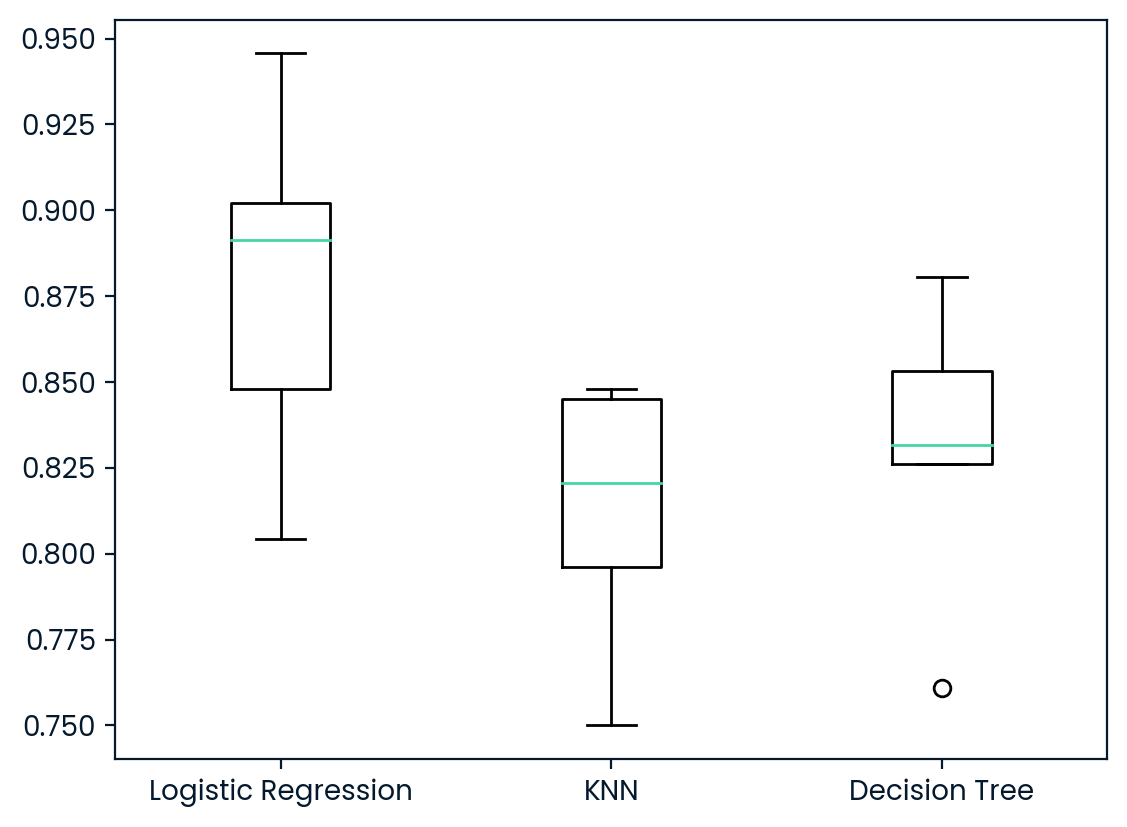

In [78]:
# Choose the best model 
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {"Logistic Regression": LogisticRegression(),"KNN": KNeighborsClassifier(), "Decision Tree": DecisionTreeClassifier()}

results = []
for model_test in models.values():     
    kf = KFold(n_splits=6, random_state=42, shuffle=True)     
    cv_results = cross_val_score(model_test, X_train_final, y_train, cv=kf) 
    results.append(cv_results)
plt.boxplot(results, labels=models.keys())
plt.show()


In [79]:
for name_test, model_test in models.items():
    model_test.fit(X_train_final,y_train)
    test_score = model_test.score(X_test_final, y_test)
    print("{} Test Set Accuracy: {}".format(name_test, test_score))

Logistic Regression Test Set Accuracy: 0.8188405797101449
KNN Test Set Accuracy: 0.8405797101449275
Decision Tree Test Set Accuracy: 0.7753623188405797


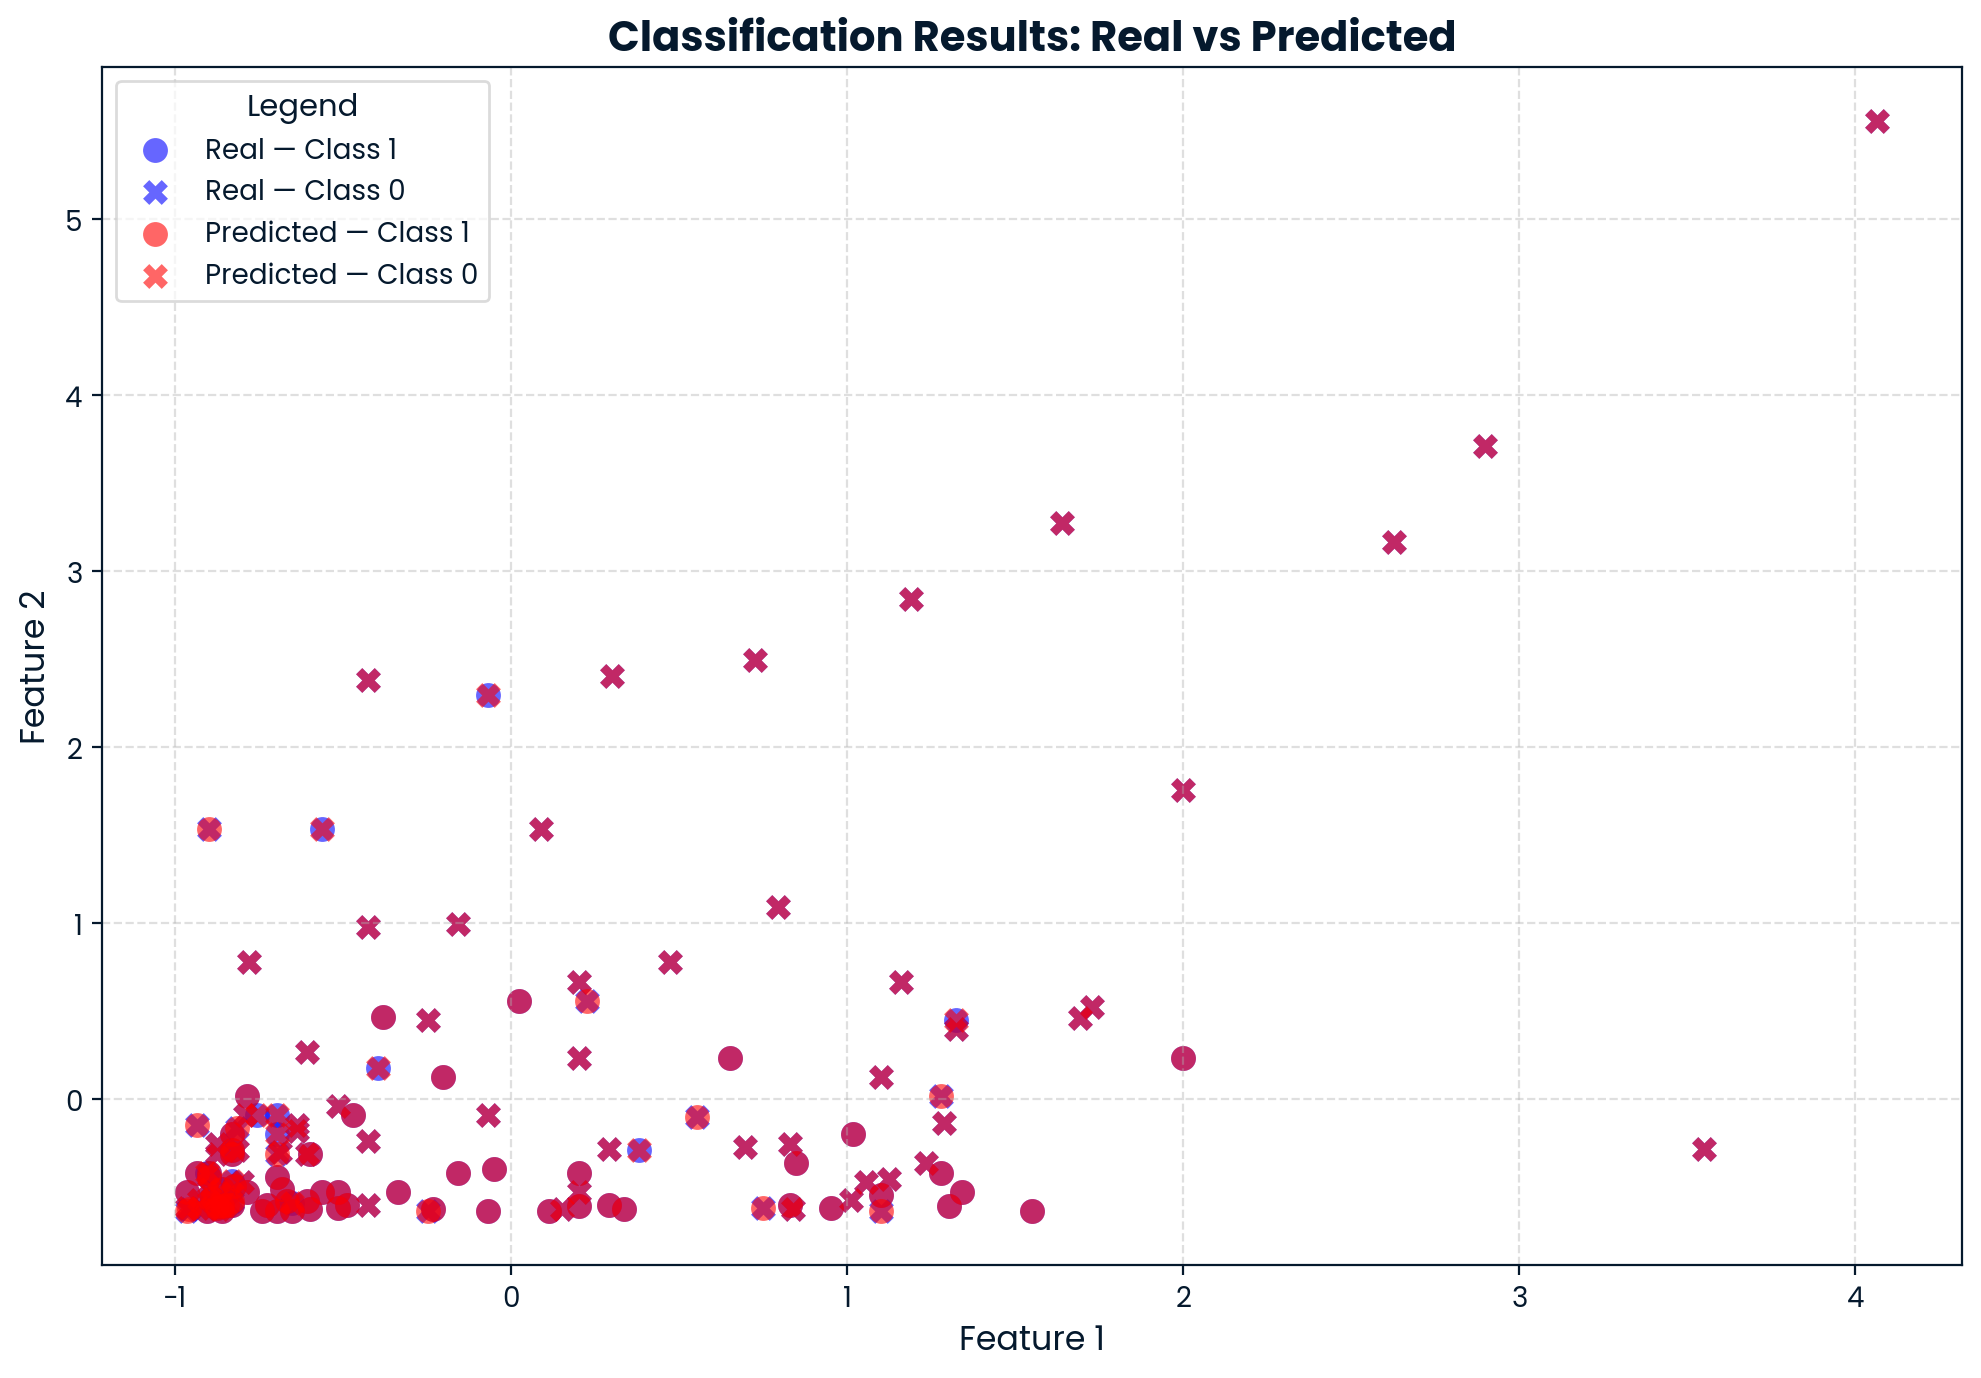

In [110]:
# --- Choose your two features to plot ---
feature_x = 1  # Change to your feature index or name
feature_y = 2  # Change to your feature index or name

# Extract the two features from the test set
X_plot = X_test_final.values if hasattr(X_test_final, 'values') else X_test_final
x = X_plot[:, feature_x]
y = X_plot[:, feature_y]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title("Classification Results: Real vs Predicted", fontsize=15, fontweight='bold')

datasets = [
    (y_test, 'blue', 'Real'),
    (y_pred, 'red',  'Predicted'),
]

markers = {1: 'o', 0: 'X'}
labels  = {1: 'Class 1', 0: 'Class 0'}

for values, color, source in datasets:
    for cls, marker in markers.items():
        mask = values == cls
        ax.scatter(x[mask], y[mask],
                   c=color,
                   marker=marker,
                   s=80,
                   alpha=0.6,
                   edgecolors='white',
                   linewidth=0,
                   label=f'{source} — {labels[cls]}')

ax.set_xlabel(f"Feature {feature_x}", fontsize=12)
ax.set_ylabel(f"Feature {feature_y}", fontsize=12)
ax.legend(title="Legend", fontsize=10, title_fontsize=11,
          loc='best', framealpha=0.7)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
#plt.savefig("classification_plot.png", dpi=150, bbox_inches='tight')
plt.show()